In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/it25102034heshaniam/dataset/cleaned_market_data.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("import Successfully")

import Successfully


In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

/kaggle/input/datasets/it25102034heshaniam/dataset/cleaned_market_data.csv


In [4]:
import pandas as pd

df = pd.read_csv(r'/kaggle/input/datasets/it25102034heshaniam/dataset/cleaned_market_data.csv')

df.head()

,Index,Date,Open,High,Low,Close,Adj Close,Volume,Volume_Available,Target
0,000001.SS,1997-07-02,1255.909058,1261.571045,1147.331055,1199.061035,1199.061035,0.0,0,0
1,000001.SS,1997-07-03,1194.676025,1194.676025,1149.939941,1150.623047,1150.623047,0.0,0,1
2,000001.SS,1997-07-04,1138.921021,1163.249023,1124.776001,1159.342041,1159.342041,0.0,0,0
3,000001.SS,1997-07-07,1161.707031,1163.447021,1085.572021,1096.818970,1096.818970,0.0,0,1
4,000001.SS,1997-07-08,1092.798950,1115.432983,1066.043945,1109.666016,1109.666016,0.0,0,1


In [5]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (110223, 10)

Columns:
['Index', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Volume_Available', 'Target']

Data Types:
Index                object
Date                 object
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume              float64
Volume_Available      int64
Target                int64
dtype: object

Missing Values:
Index               0
Date                0
Open                0
High                0
Low                 0
Close               0
Adj Close           0
Volume              0
Volume_Available    0
Target              0
dtype: int64

Duplicate Rows:
0


In [6]:
df.shape

(110223, 10)

In [7]:
df.columns

Index(['Index', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'Volume_Available', 'Target'],
      dtype='object')

In [ ]:
df.info()

In [9]:
df.isnull().sum()

Index               0
Date                0
Open                0
High                0
Low                 0
Close               0
Adj Close           0
Volume              0
Volume_Available    0
Target              0
dtype: int64

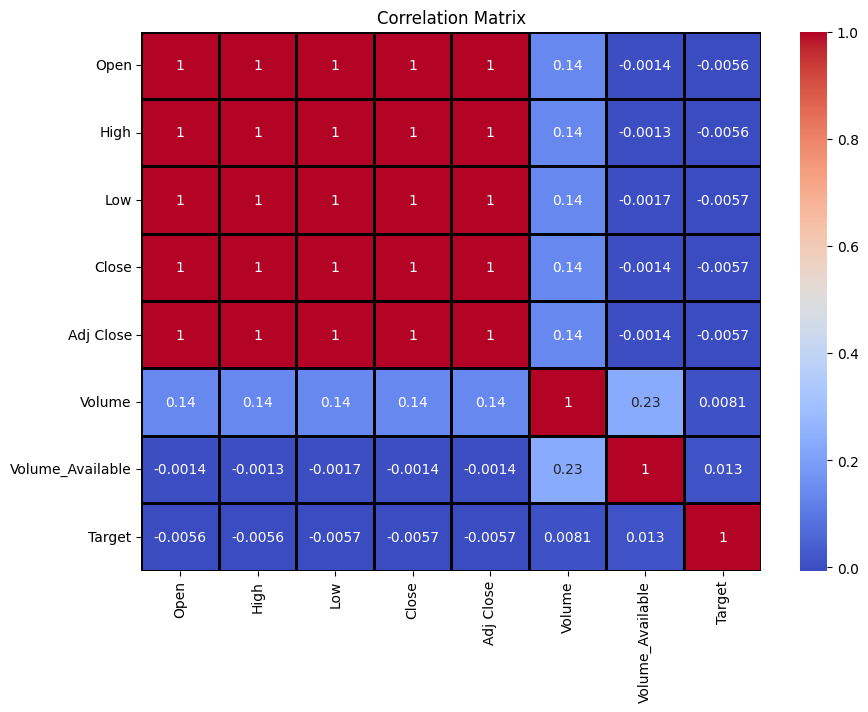

In [10]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=1,
    linecolor="black"
)

plt.title("Correlation Matrix")
plt.show()

In [13]:
if 'Date' in df.columns:
    df.drop('Date', axis=1, inplace=True)

In [ ]:
X = df.drop('Target', axis=1)

y = df['Target']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

NameError: name 'X' is not defined

In [15]:
if 'Date' in df.columns:
    df.drop('Date', axis=1, inplace=True)
    
    X = df.drop('Target', axis=1)

y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
X_train.dtypes

NameError: name 'X' is not defined

In [16]:
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
df = df.iloc[:-1]
X = df[
    [
        'Open',
        'High',
        'Low',
        'Close',
        'Adj Close',
        'Volume'
    ]
]

y = df['Target']
print(X.head())
print(y.head())
print(df.columns.tolist())

          Open         High          Low        Close    Adj Close  Volume
0  1255.909058  1261.571045  1147.331055  1199.061035  1199.061035     0.0
1  1194.676025  1194.676025  1149.939941  1150.623047  1150.623047     0.0
2  1138.921021  1163.249023  1124.776001  1159.342041  1159.342041     0.0
3  1161.707031  1163.447021  1085.572021  1096.818970  1096.818970     0.0
4  1092.798950  1115.432983  1066.043945  1109.666016  1109.666016     0.0
0    0
1    1
2    0
3    1
4    1
Name: Target, dtype: int64
['Index', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Volume_Available', 'Target']


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (88177, 6)
Testing data: (22045, 6)


In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

scaler.fit_transform(X_train)

scaler.transform(X_test)

array([[ 0.4246733 ,  0.41704462,  0.43306728,  0.42483018,  0.42484694,
        -0.29605914],
       [-0.53421192, -0.53557765, -0.5414584 , -0.54143328, -0.54140605,
        -0.29602734],
       [ 0.18550417,  0.18268211,  0.18883065,  0.18902355,  0.18904287,
        -0.26184391],
       ...,
       [-0.55607401, -0.5516021 , -0.55400767, -0.54981222, -0.54978489,
        -0.29603226],
       [-0.81000997, -0.80954559, -0.81045861, -0.81067355, -0.81064339,
        -0.29602748],
       [ 0.4860882 ,  0.48347338,  0.49041721,  0.49074847,  0.49076451,
         3.31343406]])

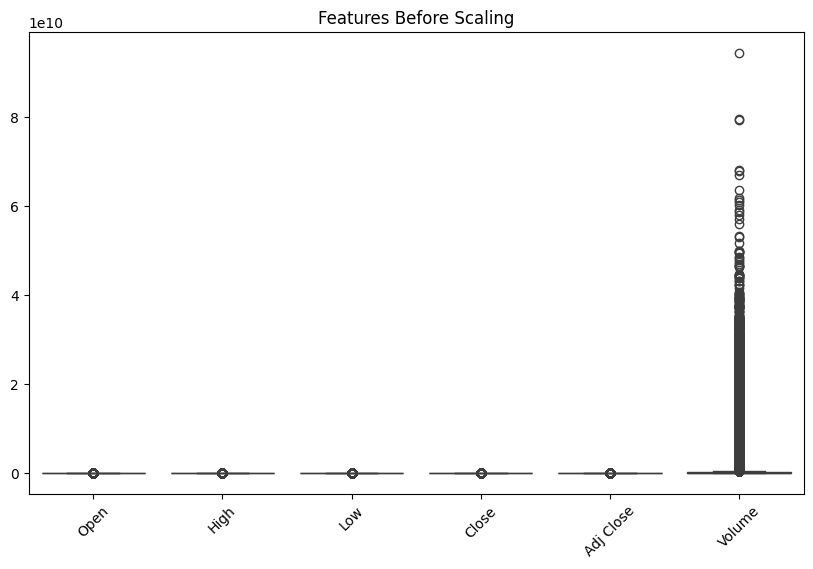

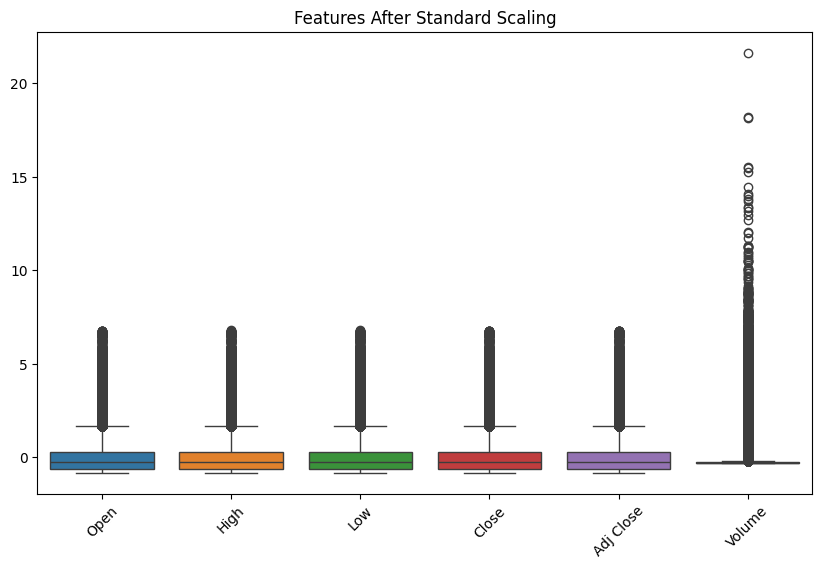

In [19]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=X_train)

plt.title("Features Before Scaling")
plt.xticks(rotation=45)
plt.show()

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

plt.figure(figsize=(10, 6))

sns.boxplot(data=X_train_scaled_df)

plt.title("Features After Standard Scaling")
plt.xticks(rotation=45)
plt.show()

In [20]:
print("Means after scaling:")
print(X_train_scaled_df.mean())

print("\nStandard deviations after scaling:")
print(X_train_scaled_df.std())

Means after scaling:
Open         1.281043e-16
High         7.707612e-17
Low          1.936573e-16
Close        4.865103e-17
Adj Close    9.581130e-17
Volume       2.965396e-17
dtype: float64

Standard deviations after scaling:
Open         1.000006
High         1.000006
Low          1.000006
Close        1.000006
Adj Close    1.000006
Volume       1.000006
dtype: float64


In [22]:
from sklearn.feature_selection import SelectKBest, f_regression


selector = SelectKBest(
    score_func=f_regression,
    k=5
)


X_train_selected = selector.fit_transform(
    X_train_scaled,
    y_train
)


X_test_selected = selector.transform(
    X_test_scaled
)
print(X_train_selected.shape)
print(X_test_selected.shape)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


model = LinearRegression()


model.fit(
    X_train_selected,
    y_train
)


y_pred = model.predict(
    X_test_selected
)


mse = mean_squared_error(
    y_test,
    y_pred
)


r2 = r2_score(
    y_test,
    y_pred
)


print("MSE:", mse)
print("R2 Score:", r2)

(88177, 5)
(22045, 5)
MSE: 0.24969604451626248
R2 Score: -0.0025718634337856816
